# **Importing Libraries**

In [9]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

In [10]:
# Google Colab mount - commented out for local execution
# from google.colab import drive
# drive.mount('/content/drive')
print("Running locally - Colab mount not needed")

Running locally - Colab mount not needed


# **Extracting Dataset with having 7200 Total Images**

In [11]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path: /kaggle/input/brain-tumor-mri-dataset


In [12]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 4

train_ds = tf.keras.utils.image_dataset_from_directory(
    path + "/Training",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    path + "/Testing",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


# ***Custom CNN Architecture***

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, Dense, BatchNormalization,
    Dropout, GlobalAveragePooling2D, MaxPooling2D, Multiply,
    Reshape, Activation, Add
)

# Hyperparameters 
l2_reg      = 1e-4
img_size    = IMG_SIZE          # change to your actual size
num_classes = 4
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)


# Building blocks

def swish(x):
    return x * tf.keras.activations.sigmoid(x)


def se_block(x, ratio=16):
    """Squeeze-and-Excitation: re-weights channels by global context."""
    ch = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Reshape((1, 1, ch))(se)
    se = Dense(max(ch // ratio, 8), activation='relu',
               kernel_regularizer=regularizers.l2(l2_reg), use_bias=False)(se)
    se = Dense(ch, activation='sigmoid',
               kernel_regularizer=regularizers.l2(l2_reg), use_bias=False)(se)
    return Multiply()([x, se])


def dw_sep_conv(x, filters, dropout=0.2):
    """Depthwise-separable conv: ~8× fewer params than Conv2D."""
    x = DepthwiseConv2D(3, padding='same',
                        depthwise_regularizer=regularizers.l2(l2_reg),
                        use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation(swish)(x)
    x = Conv2D(filters, 1,
               kernel_regularizer=regularizers.l2(l2_reg),
               use_bias=False)(x)       # pointwise
    x = BatchNormalization()(x)
    x = Activation(swish)(x)
    x = Dropout(dropout)(x)
    return x


def inverted_residual_se(x, filters, expand_ratio=4, dropout=0.25):
    """
    MobileNetV2-style inverted residual + SE block.
    Shortcut lets gradients bypass the block → faster convergence.
    """
    in_ch = x.shape[-1]
    expanded = filters * expand_ratio

    # Shortcut projection (1×1 conv to match channels if needed)
    shortcut = (Conv2D(filters, 1, use_bias=False,
                       kernel_regularizer=regularizers.l2(l2_reg))(x)
                if in_ch != filters else x)

    # Expand → Depthwise → SE → Project
    y = Conv2D(expanded, 1,
               kernel_regularizer=regularizers.l2(l2_reg),
               use_bias=False)(x)
    y = BatchNormalization()(y)
    y = Activation(swish)(y)

    y = DepthwiseConv2D(3, padding='same',
                        depthwise_regularizer=regularizers.l2(l2_reg),
                        use_bias=False)(y)
    y = BatchNormalization()(y)
    y = Activation(swish)(y)

    y = se_block(y)                     # channel attention

    y = Conv2D(filters, 1,
               kernel_regularizer=regularizers.l2(l2_reg),
               use_bias=False)(y)
    y = BatchNormalization()(y)
    y = Dropout(dropout)(y)

    return Add()([shortcut, y])         # residual connection


# Main model 

def create_cnn(input_shape=INPUT_SHAPE, num_classes=num_classes):
    inputs = Input(shape=input_shape)

    # Stem: standard conv to capture low-level edges
    x = Conv2D(32, 3, strides=2, padding='same',
               kernel_regularizer=regularizers.l2(l2_reg),
               use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation(swish)(x)           # → H/2 × W/2 × 32

    # Block 1: light depthwise-separable feature extraction
    x = dw_sep_conv(x, 64,  dropout=0.2)
    x = dw_sep_conv(x, 64,  dropout=0.2)
    x = MaxPooling2D(2)(x)             # → H/4 × W/4 × 64

    # Block 2: inverted residual with SE (128 ch)
    x = inverted_residual_se(x, 128, dropout=0.25)
    x = inverted_residual_se(x, 128, dropout=0.25)
    x = MaxPooling2D(2)(x)             # → H/8 × W/8 × 128

    # Block 3: inverted residual with SE (256 ch)
    x = inverted_residual_se(x, 256, dropout=0.3)
    x = inverted_residual_se(x, 256, dropout=0.3)
    x = MaxPooling2D(2)(x)             # → H/16 × W/16 × 256

    # Block 4: high-level depthwise-separable (512 ch)
    x = dw_sep_conv(x, 512, dropout=0.3)
    x = se_block(x)                    # global channel re-weighting

    # Head: global pooling replaces Flatten + Dense 4096
    x = GlobalAveragePooling2D()(x)    # → 512-d vector

    # MLP classifier
    x = Dense(256, kernel_regularizer=regularizers.l2(l2_reg),
              use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('gelu')(x)
    x = Dropout(0.4)(x)

    x = Dense(128, kernel_regularizer=regularizers.l2(l2_reg),
              use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('gelu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='OptimisedCNN')


model = create_cnn()
model.summary()

Model: "OptimisedCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_14 │ (None, 112, 112,  │        288 │ activation_34[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 112, 112,  │      2,048 │ activation_35[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 112, 112,  │          0 │ activation_36[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_15 │ (None, 112, 112,  │        576 │ dropout_18[0][0]  │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 112, 112,  │      4,096 │ activation_37[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 112, 112,  │          0 │ batch_normalizat

 Total params: 1,914,820 (7.30 MB)

 Trainable params: 1,898,180 (7.24 MB)

 Non-trainable params: 16,640 (65.00 KB)

In [15]:
import tensorflow as tf

# Optimizer
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    weight_decay=1e-4        # AdamW-style — works with your l2_reg
)

# Compile 
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Learning rate schedule
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # halve LR when plateau
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,   # rolls back to best epoch automatically
    verbose=1
)

# Checkpoint — saves only the best model 
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [16]:
# Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[lr_scheduler, early_stop, checkpoint]
)

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6120 - auc: 0.8342 - loss: 1.5118 - precision: 0.6954 - recall: 0.4552
Epoch 1: val_accuracy improved from None to 0.25000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 127s 159ms/step - accuracy: 0.6866 - auc: 0.8889 - loss: 1.3504 - precision: 0.7615 - recall: 0.5638 - val_accuracy: 0.2500 - val_auc: 0.5284 - val_loss: 3.2648 - val_precision: 0.2500 - val_recall: 0.2500 - learning_rate: 0.0010
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7861 - auc: 0.9434 - loss: 1.1098 - precision: 0.8362 - recall: 0.7256
Epoch 2: val_accuracy improved from 0.25000 to 0.33187, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 45s 130ms/step - accuracy: 0.8032 - auc: 0.9509 - loss: 1.0675 - precision: 0.8483 - recall: 0.7487 - val_accuracy: 0.3319 - val_auc: 0.7073 - val_loss: 2.

In [17]:
# Model testing using test dataset
results = model.evaluate(val_ds)
loss = results[0]
accuracy = results[1]
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy*100:.4f}%')

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9413 - auc: 0.9865 - loss: 0.5591 - precision: 0.9504 - recall: 0.9337
Test Loss: 0.5591
Test Accuracy: 94.1250%


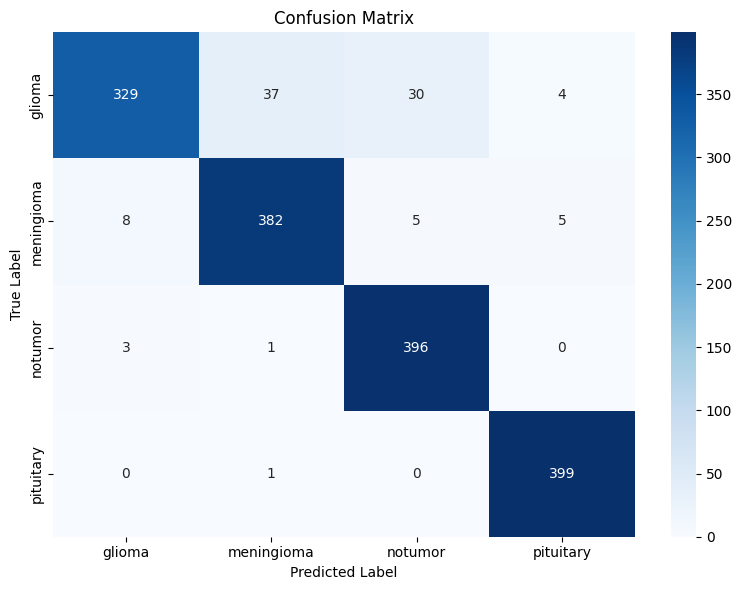

              precision    recall  f1-score   support

      glioma       0.97      0.82      0.89       400
  meningioma       0.91      0.95      0.93       400
     notumor       0.92      0.99      0.95       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']  # adjust if order is different

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Detailed report
print(classification_report(y_true, y_pred, target_names=class_names))

In [19]:
# Save the final model locally so it persists
model.save("brain_tumor_model_CustomCNN.keras")
print("Model saved locally!")

Model saved locally!


In [29]:
model = tf.keras.models.load_model(
    "brain_tumor_model_CustomCNN.keras",
    custom_objects={"swish": swish}
)
print("Model loaded!")
model.summary()

Model loaded!


Model: "OptimisedCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_14 │ (None, 112, 112,  │        288 │ activation_34[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 112, 112,  │      2,048 │ activation_35[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 112, 112,  │          0 │ activation_36[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_15 │ (None, 112, 112,  │        576 │ dropout_18[0][0]  │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 112, 112,  │      4,096 │ activation_37[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 112, 112,  │          0 │ batch_normalizat

 Total params: 5,711,182 (21.79 MB)

 Trainable params: 1,898,180 (7.24 MB)

 Non-trainable params: 16,640 (65.00 KB)

 Optimizer params: 3,796,362 (14.48 MB)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
True Label : notumor
Image Path : /kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_38.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Class: notumor


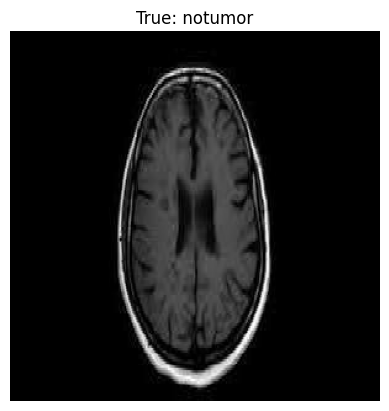

In [31]:
import random
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
import numpy as np

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

# Load the trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/brain_tumor_model.keras")

# Define class names, as they were determined during dataset loading
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(300, 300))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    predicted_class = class_names[np.argmax(score)]
    print(f"Predicted Class: {predicted_class}")

# Pick a random class, then a random image from that class
test_dir = path + "/Testing"

random_class = random.choice(os.listdir(test_dir))
random_image = random.choice(os.listdir(os.path.join(test_dir, random_class)))
img_path = os.path.join(test_dir, random_class, random_image)

print(f"True Label : {random_class}")
print(f"Image Path : {img_path}")

# Predict
predict_image(img_path)

# Show the image
img = tf.keras.utils.load_img(img_path, target_size=(300, 300))
plt.imshow(img)
plt.title(f"True: {random_class}")
plt.axis('off')
plt.show()